<a href="https://colab.research.google.com/github/akki003-star/Assignment/blob/main/pima_indians_diabetes_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scipy


In [ ]:
import pandas as pd
df = pd.read_csv("pima-indians-diabetes.csv")
print(df)

      6  148  72  35    0  33.6  0.627  50  1
0     1   85  66  29    0  26.6  0.351  31  0
1     8  183  64   0    0  23.3  0.672  32  1
2     1   89  66  23   94  28.1  0.167  21  0
3     0  137  40  35  168  43.1  2.288  33  1
4     5  116  74   0    0  25.6  0.201  30  0
..   ..  ...  ..  ..  ...   ...    ...  .. ..
762  10  101  76  48  180  32.9  0.171  63  0
763   2  122  70  27    0  36.8  0.340  27  0
764   5  121  72  23  112  26.2  0.245  30  0
765   1  126  60   0    0  30.1  0.349  47  1
766   1   93  70  31    0  30.4  0.315  23  0

[767 rows x 9 columns]


In [ ]:
df.shape

(768, 9)

In [ ]:
import pandas as pd
import numpy as np

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

df = pd.read_csv("pima-indians-diabetes.csv", names=columns)

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
zero_counts = (df == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


if you want to gofast go alone but if you want to go far go together

In [ ]:
missing_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

| Column          | `0` ni missing ga enduku consider chestham?                    |
| --------------- | -------------------------------------------------------------- |
| `Glucose`       | Glucose measurement 0 meaningful physiological reading kaadu   |
| `BloodPressure` | Diastolic BP 0 valid measurement kaadu                         |
| `SkinThickness` | Dataset measurement context lo 0 means measurement unavailable |
| `Insulin`       | 0 often means insulin measurement wasn't recorded              |
| `BMI`           | BMI 0 valid body measurement kaadu                             |


In [ ]:
df[missing_columns]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148,72,35,0,33.6
1,85,66,29,0,26.6
2,183,64,0,0,23.3
3,89,66,23,94,28.1
4,137,40,35,168,43.1
...,...,...,...,...,...
763,101,76,48,180,32.9
764,122,70,27,0,36.8
765,121,72,23,112,26.2
766,126,60,0,0,30.1


In [ ]:
# conver 0 into NaN
df[missing_columns] = df[missing_columns].replace(0,np.nan)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# count missing values
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
print(df[missing_columns].isna().sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
 # To calculate percentages:
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64


# Number of rows containing missing data: axis=1 columns axis=0 row   
Idi oka column ni kaadu — DataFrame lo unna all columns ni check chestundi.
Glucose   BP     BMI
120       70     25.5    → False
NaN       80     30.2    → True
100       NaN    27.5    → True
110       75     NaN     → True

In [ ]:

print(df.isnull().any(axis=1).sum())

376


In [ ]:
print(df.isnull().any(axis=0).sum())

5


7. Removing missing data

In [ ]:
# Remove rows containing any NaN before 768 rows
print("Before:", df.shape)

df_removed = df.dropna()

print("After:", df_removed.shape)

Before: (768, 9)
After: (392, 9)


8. Better option: Fill missing values

In [ ]:
median_value = df['Glucose'].median()

df['Glucose'] = df['Glucose'].fillna(median_value)

In [ ]:
# For all five columns:
for column in missing_columns:
    df[column] = df[column].fillna(df[column].median())

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


80, 85, 90, 95, 100, 600
600 is an extreme value/outlier.

Mean gets pulled upward, while median is less affected by that extreme value. That's why median is often a useful baseline for skewed numeric data.

9. Your complete beginner cleaning code

In [ ]:
import pandas as pd
import numpy as np

# --------------------------------
# 1. Column names
# --------------------------------

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# --------------------------------
# 2. Load dataset
# --------------------------------

df = pd.read_csv(
    "pima-indians-diabetes.csv",
    names=columns
)

# --------------------------------
# 3. Understand dataset
# --------------------------------

print(df.head())

print(df.shape)

df.info()

print(df.describe())

# --------------------------------
# 4. Check normal missing values
# --------------------------------

print(df.isnull().sum())

# --------------------------------
# 5. Check zero values
# --------------------------------

print((df == 0).sum())

# --------------------------------
# 6. Columns where 0 means missing
# --------------------------------

missing_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# --------------------------------
# 7. Mark 0 as NaN
# --------------------------------

df[missing_columns] = df[missing_columns].replace(0, np.nan)

# --------------------------------
# 8. Check missing values again
# --------------------------------

print(df.isnull().sum())

# --------------------------------
# 9. Missing percentage
# --------------------------------

print(df.isnull().mean() * 100)

# --------------------------------
# 10. Fill missing values
# --------------------------------

for column in missing_columns:
    df[column] = df[column].fillna(df[column].median())

# --------------------------------
# 11. Verify
# --------------------------------

print(df.isnull().sum())

# --------------------------------
# 12. Check duplicates
# --------------------------------

print("Duplicates:", df.duplicated().sum())

# --------------------------------
# 13. Final dataset
# --------------------------------

print(df.head())

print("Final Shape:", df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

Raw Dataset
     ↓
df.head()
df.shape
df.info()
df.describe()
     ↓
Check Missing Values
df.isnull().sum()
     ↓
Check Invalid Values
(df == 0).sum()
     ↓
Mark Invalid Values
0 → NaN
     ↓
Analyze Missing %
     ↓
Decide
 ┌──────────────┐
 ↓              ↓
Remove         Fill
dropna()       fillna()
                ↓
          Mean / Median
     ↓
Check Duplicates
     ↓
Verify Again
     ↓
Clean Dataset

In [ ]:
print("Dataset Shape:", df.shape)

print("Duplicate Count:", df.duplicated().sum())

print("Duplicate Rows:")
print(df[df.duplicated()])

Dataset Shape: (767, 9)
Duplicate Count: 0
Duplicate Rows:
Empty DataFrame
Columns: [6, 148, 72, 35, 0, 33.6, 0.627, 50, 1]
Index: []


# 14. Check outliers using IQR

In [ ]:

numeric_columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))


Column: Pregnancies
Q1: 1.0
Q3: 6.0
IQR: 5.0
Lower Limit: -6.5
Upper Limit: 13.5
Number of Outliers: 4

Column: Glucose
Q1: 99.0
Q3: 140.0
IQR: 41.0
Lower Limit: 37.5
Upper Limit: 201.5
Number of Outliers: 5

Column: BloodPressure
Q1: 62.0
Q3: 80.0
IQR: 18.0
Lower Limit: 35.0
Upper Limit: 107.0
Number of Outliers: 45

Column: SkinThickness
Q1: 0.0
Q3: 32.0
IQR: 32.0
Lower Limit: -48.0
Upper Limit: 80.0
Number of Outliers: 1

Column: Insulin
Q1: 0.0
Q3: 127.5
IQR: 127.5
Lower Limit: -191.25
Upper Limit: 318.75
Number of Outliers: 34

Column: BMI
Q1: 27.3
Q3: 36.6
IQR: 9.3
Lower Limit: 13.35
Upper Limit: 50.550000000000004
Number of Outliers: 19

Column: DiabetesPedigreeFunction
Q1: 0.2435
Q3: 0.625
IQR: 0.3815
Lower Limit: -0.32875000000000004
Upper Limit: 1.19725
Number of Outliers: 29

Column: Age
Q1: 24.0
Q3: 41.0
IQR: 17.0
Lower Limit: -1.5
Upper Limit: 66.5
Number of Outliers: 9


Step 15 — Understand the target variable

Your Outcome is the target:

0 → No diabetes outcome

1 → Diabetes outcome

Check its distribution

.value_counts() counts how many times each unique value appears in a column.

In [ ]:
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    267
Name: count, dtype: int64
Outcome
0    65.189048
1    34.810952
Name: proportion, dtype: float64


In [ ]:
outcome_counts = df['Outcome'].value_counts()

print("No Diabetes:", outcome_counts[0])
print("Diabetes:", outcome_counts[1])

No Diabetes: 500
Diabetes: 267


Step 16 — Start EDA

Question 1: Does glucose differ between outcomes?

In [ ]:
print(
    df.groupby('Outcome')['Glucose'].agg(
        ['count', 'mean', 'median', 'min', 'max']
    )
)

         count       mean  median  min  max
Outcome                                    
0          500  109.98000   107.0    0  197
1          267  141.23221   140.0    0  199


Question 2: Does BMI differ?

In [ ]:
print(
    df.groupby('Outcome')['BMI'].agg(
        ['count', 'mean', 'median', 'min', 'max']
    )
)

         count       mean  median  min   max
Outcome                                     
0          500  30.304200   30.05  0.0  57.3
1          267  35.148315   34.30  0.0  67.1


Question 3: Does age differ?

In [ ]:
print(
    df.groupby('Outcome')['Age'].agg(
        ['count', 'mean', 'median', 'min', 'max']
    )
)

         count       mean  median  min  max
Outcome                                    
0          500  31.190000    27.0   21   81
1          267  37.018727    36.0   21   70


Question 4: Which variables are correlated with Outcome?

In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.465856
BMI                         0.292695
Age                         0.236417
Pregnancies                 0.221087
DiabetesPedigreeFunction    0.173245
Insulin                     0.131984
SkinThickness               0.073265
BloodPressure               0.064882
Name: Outcome, dtype: float64


Step 17 — Create your first visualization

Now install/import Matplotlib:

In [ ]:
import matplotlib.pyplot as plt

# Visualization 1 — Outcome distribution

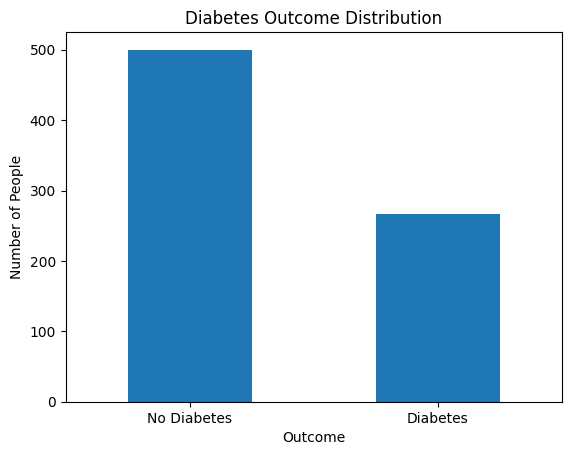

In [ ]:
# --------------------------------
# 16. Outcome distribution
# --------------------------------

df['Outcome'].value_counts().plot(
    kind='bar'
)

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of People')

plt.xticks(
    [0, 1],
    ['No Diabetes', 'Diabetes'],
    rotation=0
)

plt.show()

# Step 18 — Glucose vs Outcome

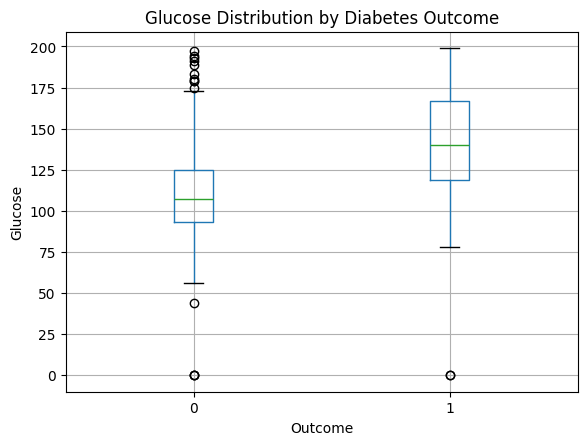

In [ ]:
# --------------------------------
# 17. Glucose vs Outcome
# --------------------------------

df.boxplot(
    column='Glucose',
    by='Outcome'
)

plt.title('Glucose Distribution by Diabetes Outcome')
plt.suptitle('')

plt.xlabel('Outcome')
plt.ylabel('Glucose')

plt.show()

# Step 20 — Age vs Outcome

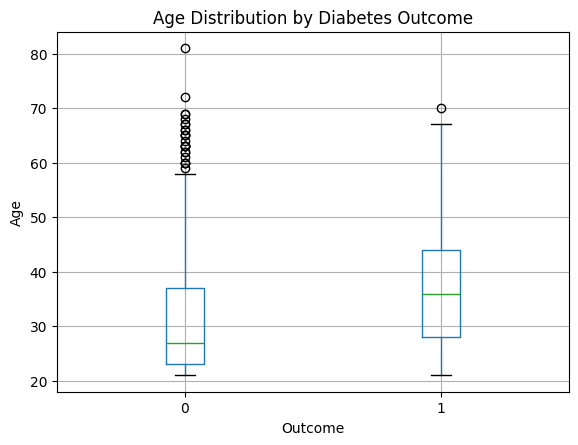

In [ ]:
# --------------------------------
# 19. Age vs Outcome
# --------------------------------

df.boxplot(
    column='Age',
    by='Outcome'
)

plt.title('Age Distribution by Diabetes Outcome')
plt.suptitle('')

plt.xlabel('Outcome')
plt.ylabel('Age')

plt.show()

# Step 21 — Correlation Heatmap

In [ ]:
import seaborn as sns

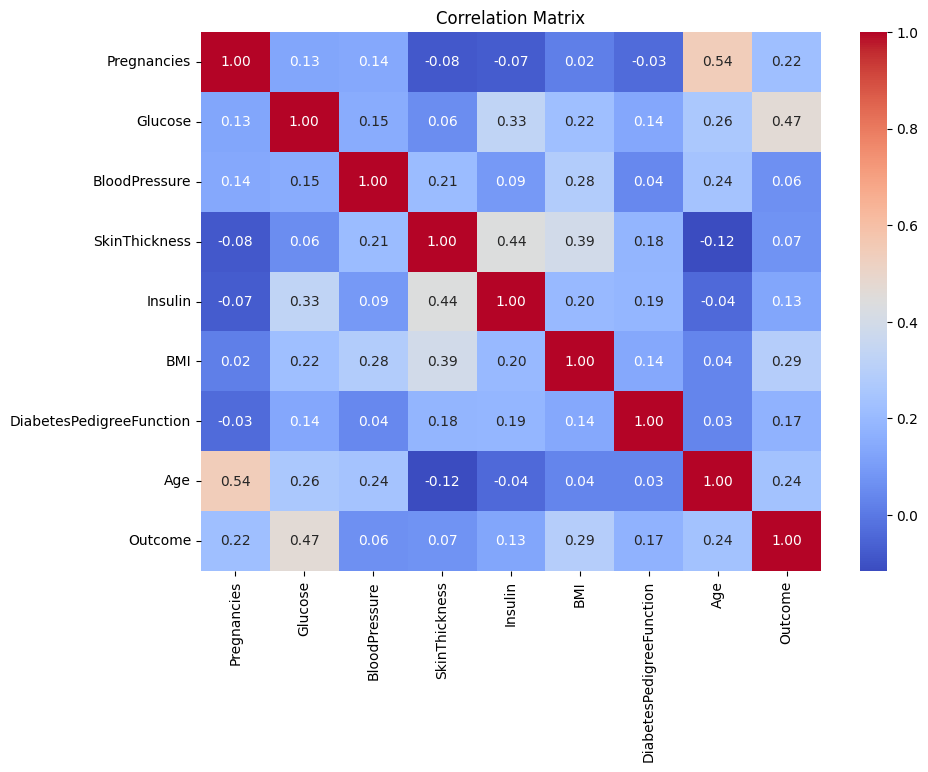

In [ ]:
# --------------------------------
# 20. Correlation Heatmap
# --------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

#Step 22 — Create a more meaningful analysis


In [ ]:
# --------------------------------
# 21. Glucose categories
# --------------------------------

df['Glucose_Category'] = pd.cut(
    df['Glucose'],
    bins=[0, 99, 125, 200],
    labels=[
        'Normal',
        'Prediabetes Range',
        'High'
    ]
)

print(
    df.groupby(
        'Glucose_Category',
        observed=False
    )['Outcome'].mean() * 100
)

Glucose_Category
Normal                7.291667
Prediabetes Range    27.737226
High                 59.121622
Name: Outcome, dtype: float64


What percentage of people in each glucose category have Outcome = 1?

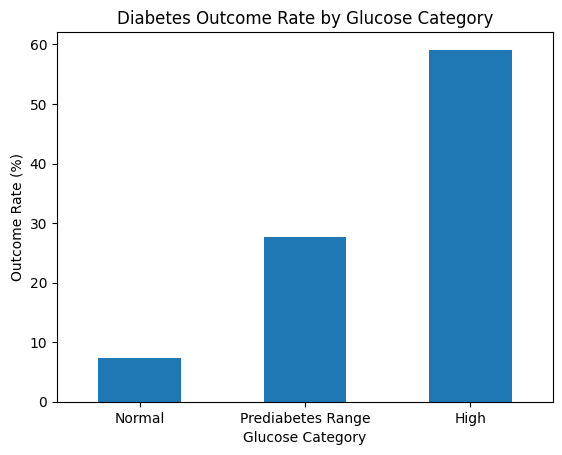

In [ ]:
glucose_outcome = (
    df.groupby(
        'Glucose_Category',
        observed=False
    )['Outcome']
    .mean() * 100
)

glucose_outcome.plot(
    kind='bar'
)

plt.title('Diabetes Outcome Rate by Glucose Category')
plt.xlabel('Glucose Category')
plt.ylabel('Outcome Rate (%)')

plt.xticks(rotation=0)

plt.show()

1. Load Dataset                 ✅
        ↓
2. Understand Dataset           ✅
        ↓
3. Check Missing Values         ✅
        ↓
4. Identify 0 as Missing       ✅
        ↓
5. Median Imputation            ✅
        ↓
6. Check Duplicates             ✅
        ↓
7. Check Outliers               ← YOU ARE HERE
        ↓
8. Target Analysis
        ↓
9. Exploratory Data Analysis
        ↓
10. Correlation Analysis
        ↓
11. Visualization
        ↓
12. Generate Insights
        ↓
13. Save Cleaned Dataset
        ↓
14. README / GitHub
        ↓
15. Resume Project

In [ ]:
# One important improvement to your current code
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [ ]:
# actually remove them if they exist:
duplicates = df.duplicated().sum()

print("Duplicates:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

Duplicates: 0
